In [1]:
import numpy as np
import qutip as qt
from qutip import gates
from qutip_qip import *
from qiskit import QuantumCircuit
from qutip_qip.qiskit import QiskitCircuitSimulator
from qiskit.visualization import plot_histogram
from qutip_qip.device import LinearSpinChain
from qutip_qip.qiskit import QiskitPulseSimulator
from qutip_qip.device import Processor, Model
import warnings
warnings.filterwarnings('ignore')

In [3]:
from qiskit.compiler import transpile
from qutip_qip.circuit import QubitCircuit
from qutip_qip.qiskit.converter import convert_qiskit_circuit
from qiskit.visualization import plot_histogram

In [4]:
class minimal_processor( Processor ):
    def __init__(self, num_qubits=2, num_levels=4, decay_rate=1/(540e-6)):
        self.model = Model(2)
        self.num_qubits = num_qubits
        self.decay_rate = decay_rate
        self.native_gates = ["rx", "rz", "cz"]
        # basis states
        self.s0 = qt.tensor(qt.fock(2,0),qt.fock(2,0))
        self.s1 = qt.tensor(qt.fock(2,0),qt.fock(2,1))
        self.sr = qt.tensor(qt.fock(2,1),qt.fock(2,0))
        self.sd = qt.tensor(qt.fock(2,1),qt.fock(2,1))
        self.states = [self.s0, self.s1, self.sr, self.sd]
        self.b_0r = 1/16
        self.b_1r = 1/16
        self.b_dr = 7/8
        self.final_unitary_t = qt.tensor([qt.tensor(qt.qeye(2),qt.qeye(2)) for x in range(self.num_qubits)])
        self.circuit = None
        return

    def make_zero_density_matrix(self):
        zero_state = qt.tensor([qt.tensor(qt.zero_ket(2),qt.zero_ket(2)) for x in range(2)])
        return zero_state*zero_state.dag()

    def make_unitary_for_Qcircuit(self, index, partial_unitary, control_gate=False):
        if self.num_qubits == 1: return partial_unitary
        else:
            if control_gate: 
                tot_qubits = self.num_qubits - 1
                if tot_qubits == 1: return partial_unitary
            else: tot_qubits = self.num_qubits
            gates = [qt.tensor(qt.qeye(2),qt.qeye(2)) for x in range(tot_qubits)]
            gates[index] = partial_unitary
            return qt.tensor(gates)

    def calculate_system_H(self, Omega_01, delta_1, Omega_r, Delta_r):
        return

    def make_collapse_operators(self):
        operators = []
        for qn in range(self.num_qubits):
            gamma_r = self.decay_rate
            s0, s1, sr, sd = self.s0, self.s1, self.sr, self.sd
            L0 = np.sqrt(self.b_0r*gamma_r) * s0*sr.dag()
            L1 = np.sqrt(self.b_1r*gamma_r) * s1*sr.dag()
            Ld = np.sqrt(self.b_dr*gamma_r) * sd*sr.dag()
            operators += [self.make_unitary_for_Qcircuit(qn, L) for L in [L0, L1, Ld]]
        return operators

    def make_expectation_operators(self):
        operators = []
        for qn in range(self.num_qubits):
            #s0, s1, sr, sd = self.s0, self.s1, self.sr, self.sd
            operators += [self.make_unitary_for_Qcircuit(qn, s*s.dag()) for s in self.states]
        return operators
    
    def RX_gate(self, angle, target, rho):
        Omega_0 = 1e6
        delta_1 = 0
        Omega_r = 0
        Delta_r = 0
        s0, s1, sr, sd = self.s0, self.s1, self.sr, self.sd
        c_ops_input = self.make_collapse_operators()
        e_ops_input = self.make_expectation_operators()
        pulse_width = angle / Omega_0
        def Omega_01_Pulse(t, t_mid, pulse_width):
            half_pulse_width = pulse_width/2
            if (t_mid-half_pulse_width) <= t <= (t_mid+half_pulse_width): return Omega_0
            else: return 0
        tot_t = pulse_width
        midpoint_t = tot_t / 2
        steps = 1000
        dt = tot_t / 1000
        times = np.linspace(0.0, tot_t, steps+1) # This should be 10 seconds of microseconds?
        def H_Rx_gate(t):
            H = (Omega_01_Pulse(t, midpoint_t, pulse_width) / 2) * (s0*s1.dag() + s1*s0.dag())
            return self.make_unitary_for_Qcircuit(target, H)
        result = qt.mesolve(H_Rx_gate, rho, times, c_ops=c_ops_input, e_ops=e_ops_input, options={"store_states" : True, "store_final_state" : True})
        #unitary_t = qt.propagator(H_Rx_gate, angle*1e-6)
        return result#, unitary_t

    def RZ_gate(self, angle, target, rho):
        # Constants
        Omega_0 = 0
        delta_1 = 0
        Omega_r = 0
        Delta_r = 0
        s0, s1, sr, sd = self.s0, self.s1, self.sr, self.sd
        c_ops_input = self.make_collapse_operators()
        e_ops_input = self.make_expectation_operators()
        T = angle/2*1e-6
        def delta_1_t(t):
            if 0 <= t < T: return 1e6
            else: return 0
        tot_t = T
        midpoint_t = tot_t / 2
        steps = 1000
        dt = tot_t / steps
        times = np.linspace(0.0, tot_t, steps+1)
        def H_Rz_Gate(t):
            H = (delta_1_t(t)*s0*s0.dag()) - (delta_1_t(t)*s1*s1.dag())
            return self.make_unitary_for_Qcircuit(target, H)
        result = qt.mesolve(H_Rz_Gate, rho, times, c_ops=c_ops_input, e_ops=e_ops_input, options={"store_states" : True, "store_final_state" : True})
        #unitary_t = qt.propagator(H_Rz_Gate, angle*1e-6)
        return result#, unitary_t

    def CZ_gate(self, control, target, rho):
        # Constants
        T = 0.54e-6 # (microseconds^-1) period
        t0_0 = (T/2)
        t0_1 = t0_0 + T
        Omega_01 = 0 #MHz
        delta_1= 0 #MHz
        Omega_r= 2*np.pi*17e6 #MHz
        Delta_r= 2*np.pi*23e6 #MHz
        s0, s1, sr, sd = self.s0, self.s1, self.sr, self.sd
        tau = .175 * T
        def Omega_1r_t(t):
            if t < T/2: t0 = t0_0
            else: t0 = t0_1
            a = np.exp(-(t0/tau)**4)
            Omega_1r = Omega_r * (np.exp(-((t-t0)**4) / tau**4) - a) / (1-a)
            return Omega_1r
        def Delta_r_t(t):
            t = t % (T/2)
            return -Delta_r * np.cos((2*np.pi / T) * t)
        c_ops = self.make_collapse_operators()
        e_ops = self.make_expectation_operators()
        #B = 2*np.pi*201.32753861e6 # MHz
        B = 2*np.pi*1000e6 # MHz
        def H_CZ(t):
            H_B = B * qt.tensor([sr,sr])*qt.tensor([sr,sr]).dag()
            H0 = ((Omega_01 / 2) * (s0*s1.dag() + s1*s0.dag())) + (delta_1*s1*s1.dag()) + ((Omega_1r_t(t)/2) * (s1*sr.dag() + (sr*s1.dag()))) + (Delta_r_t(t)*sr*sr.dag())
            H1 = ((Omega_01 / 2) * (s0*s1.dag() + s1*s0.dag())) + (delta_1*s1*s1.dag()) + ((Omega_1r_t(t)/2) * (s1*sr.dag() + (sr*s1.dag()))) + (Delta_r_t(t)*sr*sr.dag())
            H = qt.tensor([H0, qt.tensor(qt.qeye(2), qt.qeye(2))]) + qt.tensor([qt.tensor(qt.qeye(2), qt.qeye(2)), H1]) + H_B
            if control < target: return self.make_unitary_for_Qcircuit(control, H, control_gate=True)
            else: return self.make_unitary_for_Qcircuit(target, H, control_gate=True)
        tot_t = T
        steps = 1000
        dt = tot_t / steps
        tot_t = tot_t - dt
        times = np.linspace(0.0, tot_t, steps+1)
        result = qt.mesolve(H_CZ, rho, times, c_ops=c_ops, e_ops=e_ops, options={"store_states" : True, "store_final_state" : True})
        #unitary_t = qt.propagator(H_CZ, T, options={"nsteps":100000})
        return result#, unitary_t

    def generate_init_processor_state(self):
        list_qubit_states = [qt.tensor(qt.fock(2,0),qt.fock(2,0)) for x in range(self.num_qubits)]
        return qt.tensor(list_qubit_states)

    def load_circuit(self, qutip_circuit):
        self.circuit = qutip_circuit
        return 

    def run_state(self, init_state, qutip_circuit=None):
        result = None
        curr_state = init_state
        for gate in self.circuit.gates:
            H = 0
            print(gate.name, gate.arg_value)
            if gate.name == "RX": result = self.RX_gate(gate.arg_value, gate.targets[0], curr_state)
            elif gate.name == "RZ": result = self.RZ_gate(gate.arg_value, gate.targets[0], curr_state)
            elif gate.name == "CZ": result = self.CZ_gate(gate.controls[0], gate.targets[0], curr_state)
            else: print("Incompatiable Gate")
            curr_state = result.final_state
            #self.final_unitary_t = self.final_unitary_t * unitary_t
        #print(result.final_state)
        return result

    def get_final_circuit_state(self, final_state):
        dims_list = [2*x+1 for x in range(self.num_qubits)]
        return final_state.ptrace(dims_list)

# Testing

In [5]:
test_processor = minimal_processor(2)
test_circuit = QuantumCircuit(2)
test_circuit.cx(0,1)

test_circ = transpile(test_circuit, basis_gates=["rx", "rz", "cz"])

In [6]:
qc_test = convert_qiskit_circuit(test_circ)
qc_test.gates

[Gate(RZ, targets=[0], controls=None, classical controls=None, control_value=None, classical_control_value=None),
 Gate(RX, targets=[0], controls=None, classical controls=None, control_value=None, classical_control_value=None),
 Gate(RZ, targets=[0], controls=None, classical controls=None, control_value=None, classical_control_value=None),
 Gate(CZ, targets=[0], controls=[1], classical controls=None, control_value=1, classical_control_value=None),
 Gate(RZ, targets=[0], controls=None, classical controls=None, control_value=None, classical_control_value=None),
 Gate(RX, targets=[0], controls=None, classical controls=None, control_value=None, classical_control_value=None),
 Gate(RZ, targets=[0], controls=None, classical controls=None, control_value=None, classical_control_value=None)]

In [7]:
init_state = test_processor.generate_init_processor_state()
init_state

Quantum object: dims=[[2, 2, 2, 2], [1]], shape=(16, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]

In [8]:
s0_t, s1_t = qt.tensor(qt.fock(2,0),qt.fock(2,0)), qt.tensor(qt.fock(2,0),qt.fock(2,1))
init_state_test = qt.tensor(s1_t, s1_t)
test_processor.load_circuit(qc_test)
res = test_processor.run_state(init_state, qutip_circuit=init_state_test)

RZ 1.5707963267948966
RX 1.5707963267948966
RZ 1.5707963267948966
CZ None
RZ 1.5707963267948966
RX 1.5707963267948966
RZ 1.5707963267948966


In [9]:
res.final_state.ptrace([1,3])

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.58779784-4.65524497e-17j 0.        +0.00000000e+00j
  0.05820961+4.36911890e-01j 0.        +0.00000000e+00j]
 [0.        +0.00000000e+00j 0.        +0.00000000e+00j
  0.        +0.00000000e+00j 0.        +0.00000000e+00j]
 [0.05820961-4.36911890e-01j 0.        +0.00000000e+00j
  0.41220216+4.65640519e-17j 0.        +0.00000000e+00j]
 [0.        +0.00000000e+00j 0.        +0.00000000e+00j
  0.        +0.00000000e+00j 0.        +0.00000000e+00j]]

In [10]:
res.final_state.ptrace([1,3])

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.58779784-4.65524497e-17j 0.        +0.00000000e+00j
  0.05820961+4.36911890e-01j 0.        +0.00000000e+00j]
 [0.        +0.00000000e+00j 0.        +0.00000000e+00j
  0.        +0.00000000e+00j 0.        +0.00000000e+00j]
 [0.05820961-4.36911890e-01j 0.        +0.00000000e+00j
  0.41220216+4.65640519e-17j 0.        +0.00000000e+00j]
 [0.        +0.00000000e+00j 0.        +0.00000000e+00j
  0.        +0.00000000e+00j 0.        +0.00000000e+00j]]

# HH Gate

In [11]:
processor = minimal_processor(2)
pulse_circ = QuantumCircuit(2)
pulse_circ.h(0)
pulse_circ.h(1)

circuit = transpile(pulse_circ, basis_gates=["rx", "rz", "cz"])
backend = QiskitPulseSimulator(processor)
job = backend.run(circuit)
pulse_result = job.result()

RZ 1.5707963267948966
RX 1.5707963267948966
RZ 1.5707963267948966
RZ 1.5707963267948966
RX 1.5707963267948966
RZ 1.5707963267948966


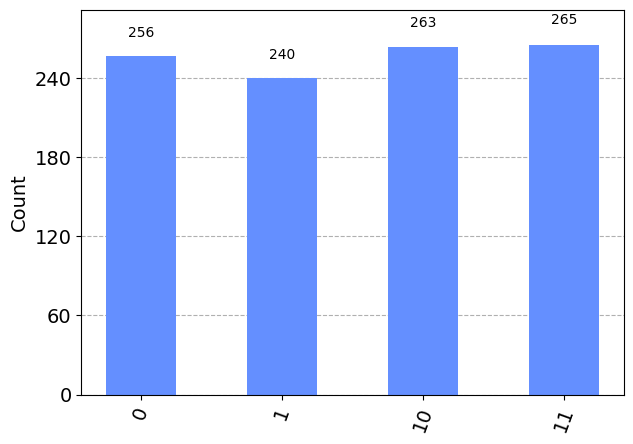

In [12]:
plot_histogram(pulse_result.get_counts())

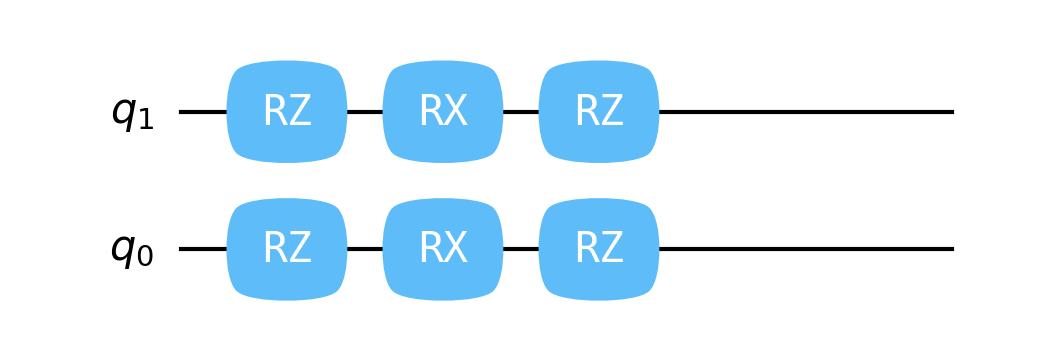

In [13]:
qc = convert_qiskit_circuit(circuit)
qc.draw("matplotlib", dpi=300)

# H CX GATE

In [14]:
processor2 = minimal_processor(2)
pulse_circ2 = QuantumCircuit(2)
pulse_circ2.h(0)
pulse_circ2.cx(0, 1)

circuit2 = transpile(pulse_circ2, basis_gates=["rx", "rz", "cz"])
backend2 = QiskitPulseSimulator(processor2)
job2 = backend2.run(circuit2)
pulse_result2 = job2.result()

RZ 1.5707963267948966
RX 1.5707963267948966
RZ 1.5707963267948966
RZ 1.5707963267948966
RX 1.5707963267948966
RZ 1.5707963267948966
CZ None
RZ 1.5707963267948966
RX 1.5707963267948966
RZ 1.5707963267948966


In [15]:
#pulse_result2.data()

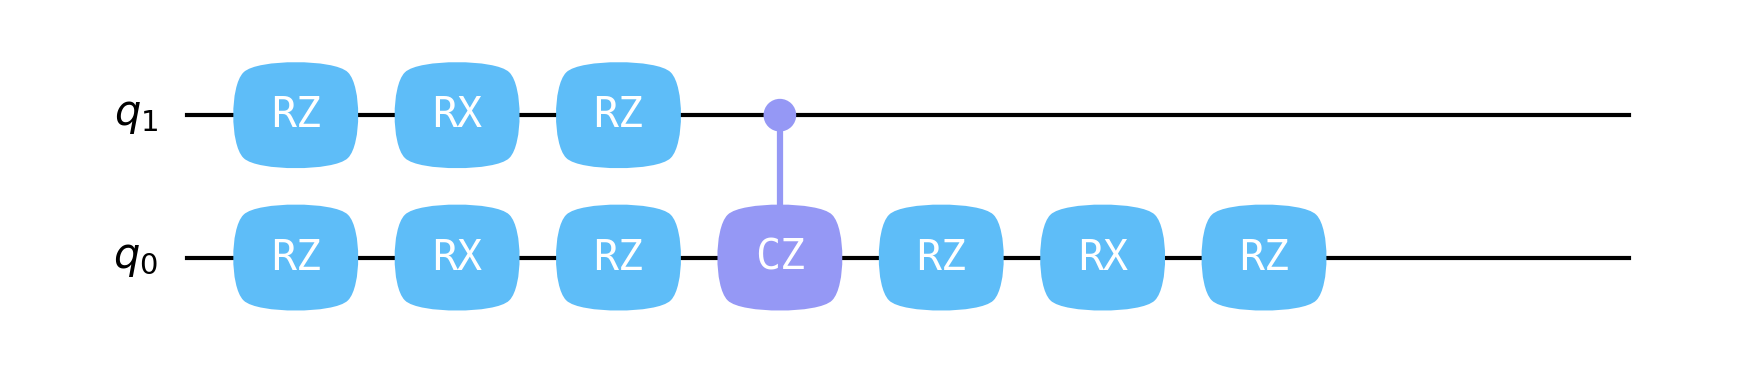

In [16]:
qc2 = convert_qiskit_circuit(circuit2)
qc2.draw("matplotlib", dpi=300)

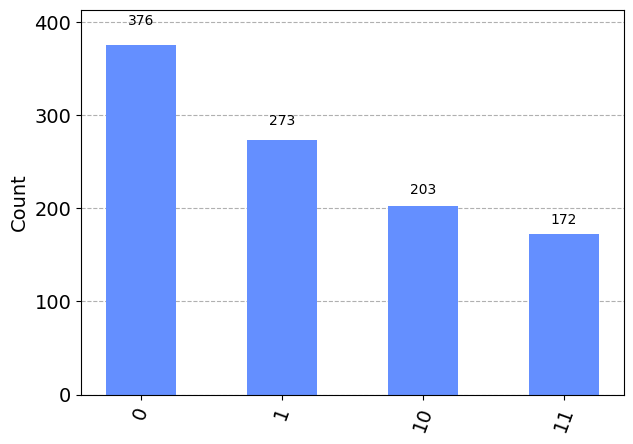

In [17]:
plot_histogram(pulse_result2.get_counts())

In [18]:
gates.cnot() * qt.tensor(gates.hadamard_transform(), qt.qeye(2)) * qt.tensor(qt.fock(2,0),qt.fock(2,0))

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.70710678]]

# H CX CX GATE

In [19]:
processorHCXCX = minimal_processor(3)
pulse_circHCXCX = QuantumCircuit(3)
pulse_circHCXCX.h(0)
pulse_circHCXCX.cx(0, 1)
pulse_circHCXCX.cx(1, 2)

circuitHCXCX = transpile(pulse_circHCXCX, basis_gates=["rx", "rz", "cz"])
backendHCXCX = QiskitPulseSimulator(processorHCXCX)
jobHCXCX = backendHCXCX.run(circuitHCXCX)
pulse_resultHCXCX = jobHCXCX.result()

RZ 1.5707963267948966
RX 1.5707963267948966
RZ 1.5707963267948966
RZ 1.5707963267948966
RX 1.5707963267948966
RZ 1.5707963267948966
CZ None
RZ 1.5707963267948966
RX 1.5707963267948966
RZ 1.5707963267948966
RZ 1.5707963267948966
RX 1.5707963267948966
RZ 1.5707963267948966
CZ None
RZ 1.5707963267948966
RX 1.5707963267948966
RZ 1.5707963267948966


In [20]:
#pulse_resultHCXCX.data()

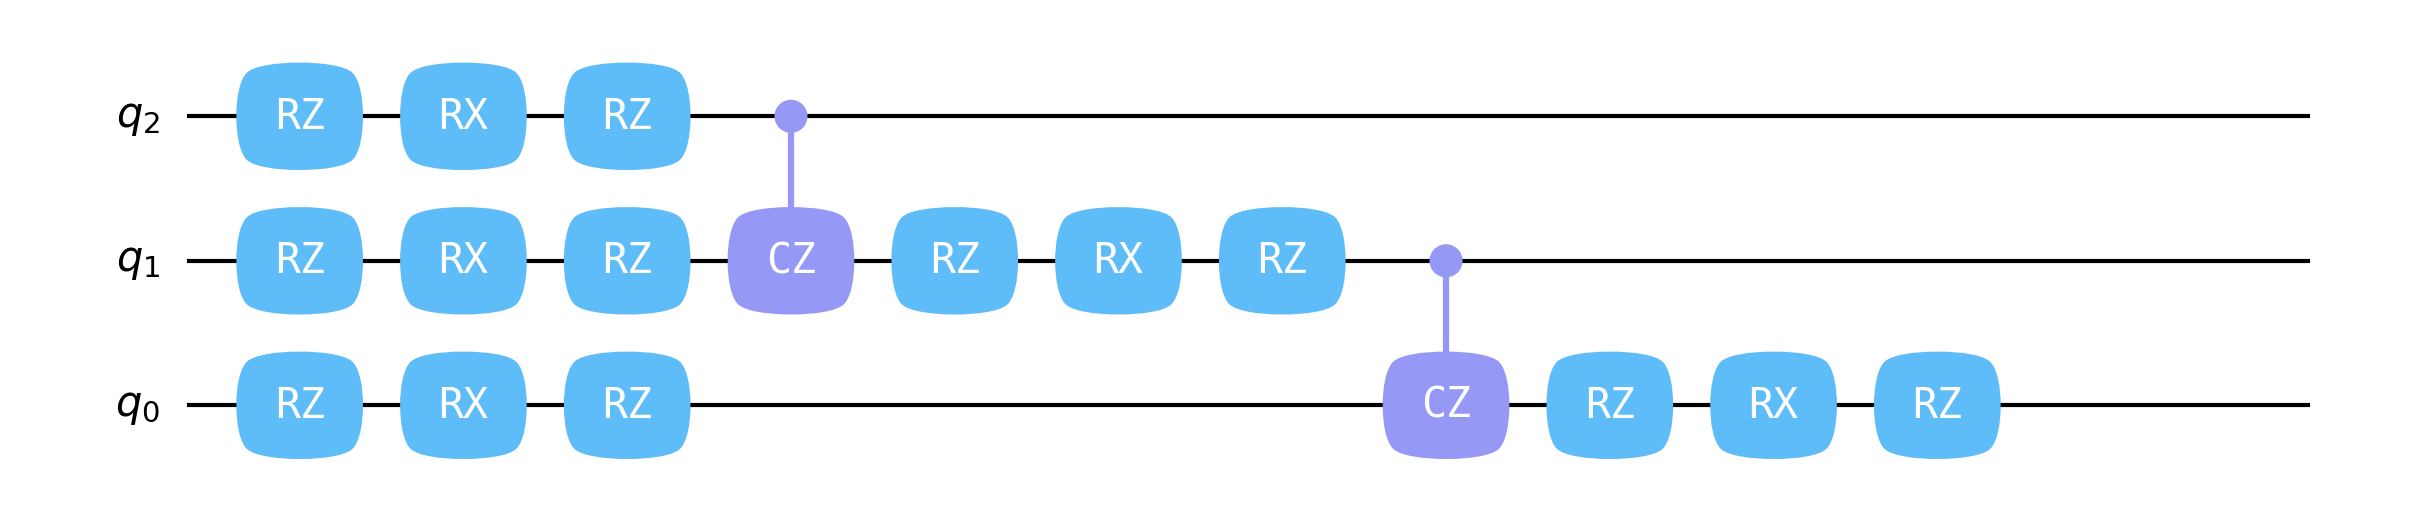

In [21]:
qcHCXCX = convert_qiskit_circuit(circuitHCXCX)
qcHCXCX.draw("matplotlib", dpi=300)

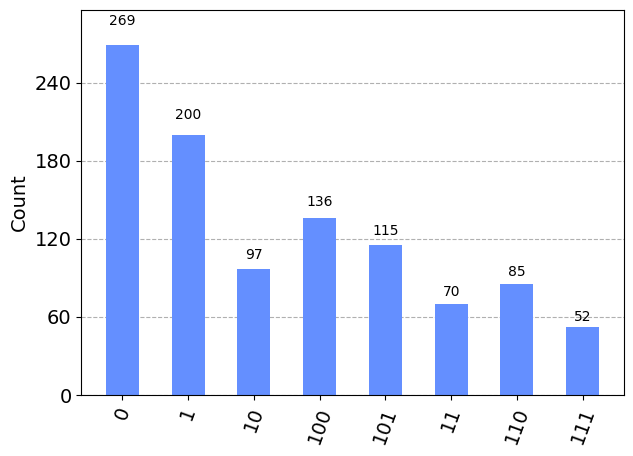

In [22]:
plot_histogram(pulse_resultHCXCX.get_counts())

In [23]:
gates.cnot() * qt.tensor(gates.hadamard_transform(), qt.qeye(2)) * qt.tensor(qt.fock(2,0),qt.fock(2,0))

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.70710678]]

# H CX CX GATE

In [24]:
processorHCXCX = minimal_processor(2)
pulse_circHCXCX = QuantumCircuit(2)
#pulse_circHCXCX.h(0)
#pulse_circHCXCX.cx(0, 1)
#pulse_circHCXCX.cx(1, 2)
pulse_circHCXCX.rz(np.pi/2, 1)
pulse_circHCXCX.rx(np.pi/2, 1)
pulse_circHCXCX.rz(np.pi/2, 1)

pulse_circHCXCX.rz(np.pi/2, 1)
pulse_circHCXCX.rx(np.pi/2, 1)
pulse_circHCXCX.rz(np.pi/2, 1)

#circuitHCXCX = transpile(pulse_circHCXCX, basis_gates=["rx", "rz", "cz"])
backendHCXCX = QiskitPulseSimulator(processorHCXCX)
jobHCXCX = backendHCXCX.run(pulse_circHCXCX)
pulse_resultHCXCX = jobHCXCX.result()

RZ 1.5707963267948966
RX 1.5707963267948966
RZ 1.5707963267948966
RZ 1.5707963267948966
RX 1.5707963267948966
RZ 1.5707963267948966


In [25]:
#pulse_resultHCXCX.data()

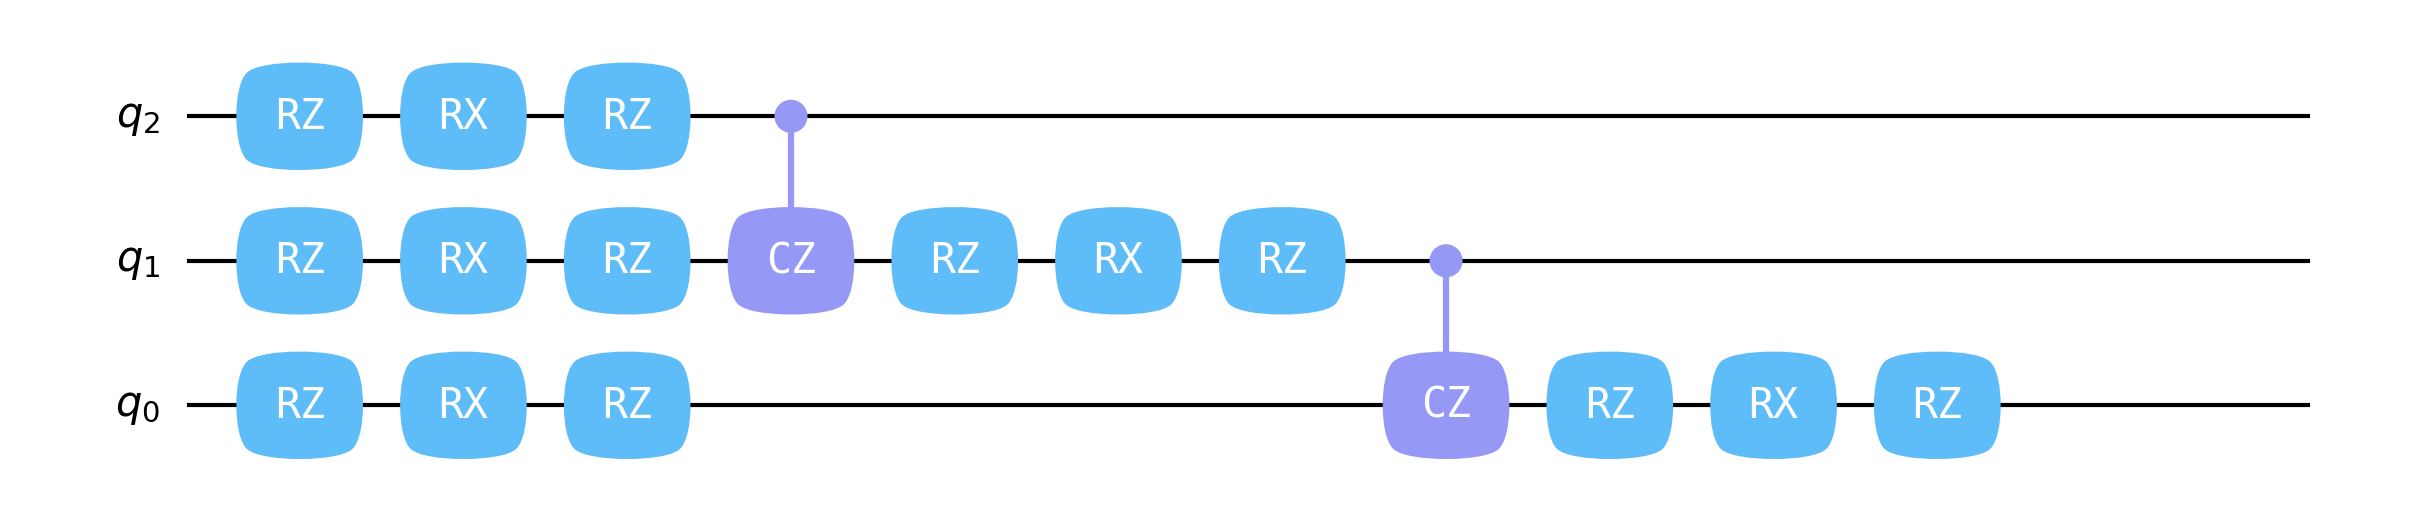

In [26]:
qcHCXCX = convert_qiskit_circuit(circuitHCXCX)
qcHCXCX.draw("matplotlib", dpi=300)

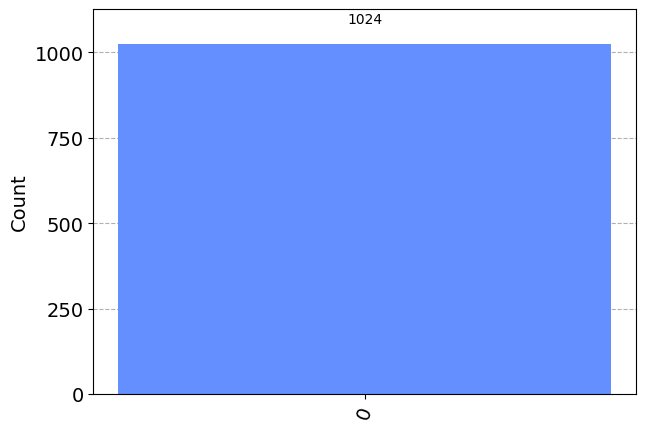

In [27]:
plot_histogram(pulse_resultHCXCX.get_counts())

In [28]:
gates.cnot() * qt.tensor(gates.hadamard_transform(), qt.qeye(2)) * qt.tensor(qt.fock(2,0),qt.fock(2,0))

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.70710678]]

# X Gate

In [29]:
processor3 = minimal_processor(2)
pulse_circ3 = QuantumCircuit(2)
pulse_circ3.x(0)

circuit3 = transpile(pulse_circ3, basis_gates=["rx", "rz", "cz"])
backend3 = QiskitPulseSimulator(processor3)
job3 = backend2.run(circuit3)
pulse_result3 = job3.result()

RX 3.141592653589793


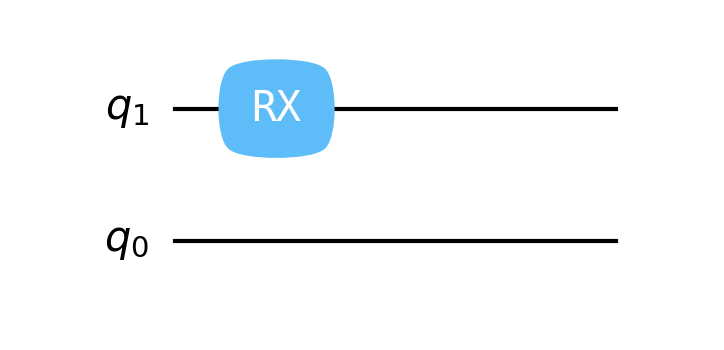

In [30]:
qc3 = convert_qiskit_circuit(circuit3)
qc3.draw("matplotlib", dpi=300)

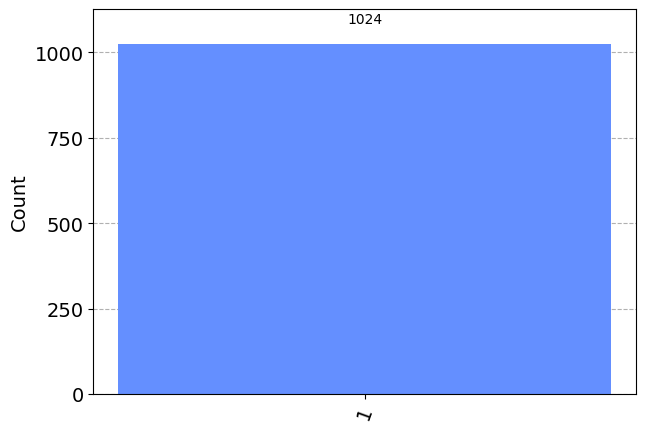

In [31]:
plot_histogram(pulse_result3.get_counts())

In [32]:
pulse_result3.data()['statevector']

DensityMatrix([[-1.00646442e-06+0.00000000e+00j,
                 0.00000000e+00-7.32222938e-06j,
                 0.00000000e+00+0.00000000e+00j,
                 0.00000000e+00+0.00000000e+00j],
               [ 0.00000000e+00+7.32222938e-06j,
                 1.00000101e+00+0.00000000e+00j,
                 0.00000000e+00+0.00000000e+00j,
                 0.00000000e+00+0.00000000e+00j],
               [ 0.00000000e+00+0.00000000e+00j,
                 0.00000000e+00+0.00000000e+00j,
                 0.00000000e+00+0.00000000e+00j,
                 0.00000000e+00+0.00000000e+00j],
               [ 0.00000000e+00+0.00000000e+00j,
                 0.00000000e+00+0.00000000e+00j,
                 0.00000000e+00+0.00000000e+00j,
                 0.00000000e+00+0.00000000e+00j]],
              dims=(2, 2))
